In [58]:
import pandas as pd 

from sklearn import set_config
set_config(display='diagram')

In [59]:
data = pd.read_csv("Telco_Churn.csv")
data.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [60]:
data.info()
print("shape :\n",data.shape)
data.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [61]:
(data["TotalCharges"] == " ").sum()

np.int64(11)

In [62]:
import numpy as np
data["TotalCharges"] = data["TotalCharges"].replace(" ",np.nan)

In [63]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"])

In [64]:
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].median())

In [65]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [66]:
data["Churn"] = data["Churn"].map({"No":0,"Yes":1})

In [67]:
# data["Churn"].head()
# data["Churn"].info()

In [68]:
data["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [69]:
data["Churn"].mean()*100

np.float64(26.536987079369588)

In [70]:
import seaborn as sns 
import matplotlib.pyplot as plt 

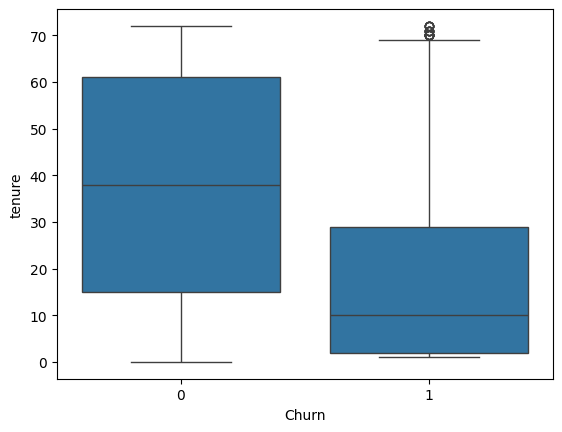

In [71]:
sns.boxplot(x="Churn",y="tenure",data=data)
plt.show()

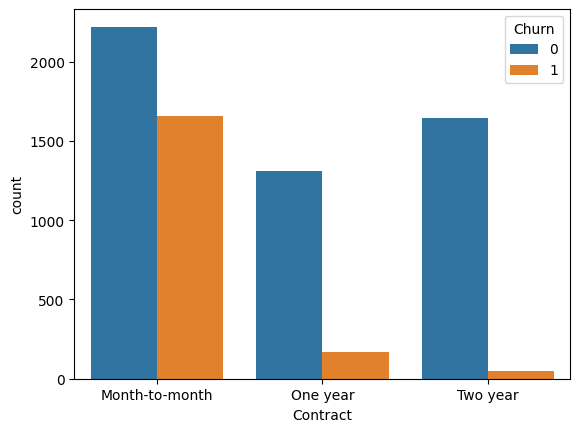

In [72]:
sns.countplot(x="Contract",hue="Churn",data=data)
plt.show()

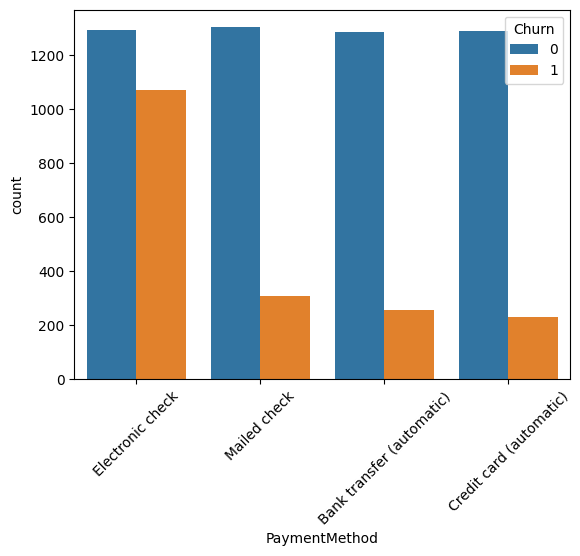

In [73]:
# plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod",hue="Churn",data=data)
plt.xticks(rotation = 45)
plt.show()

In [74]:
X = data.drop("Churn",axis=1)
y = data["Churn"]

In [75]:
X = X.drop("customerID",axis=1)

In [76]:
X.select_dtypes(include="object").shape[1]

15

In [77]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# identify categorical & numerical columns
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

# full pipeline
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=5000, class_weight='balanced'))
])

# train
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [79]:
# print(y_train.value_counts(normalize=True))
# print(y_test.value_counts(normalize=True))


In [80]:
X_test.shape

(1409, 19)

In [81]:
y_pred = model.predict(X_test)

In [82]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [83]:
print("confusion matrix :\n",confusion_matrix(y_test,y_pred))
print(f"\nAccuracy:\n",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

confusion matrix :
 [[747 288]
 [ 81 293]]

Accuracy:
 0.7381121362668559

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [84]:
y_prob = model.predict_proba(X_test)[:,1]

In [85]:
y_prob[:10]

array([0.11696742, 0.85204228, 0.14940507, 0.65878815, 0.06050352,
       0.80468427, 0.6958481 , 0.29037081, 0.00919835, 0.65384131])

In [86]:
import numpy as np 
y_pred_cust = (y_prob >= 0.5).astype(int)

In [87]:
print(classification_report(y_test,y_pred_cust))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [88]:
from sklearn.metrics import recall_score

for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_prob >= t).astype(int)
    print("Threshold:", t, " Recall:", recall_score(y_test, y_pred_t))


Threshold: 0.5  Recall: 0.7834224598930482
Threshold: 0.4  Recall: 0.8663101604278075
Threshold: 0.3  Recall: 0.9278074866310161
Threshold: 0.2  Recall: 0.9625668449197861


In [89]:
def predict_churn(customer_data, model, threshold=0.2):
    prob = model.predict_proba(customer_data)[:,1]
    return (prob >= threshold).astype(int)


In [90]:
y_pred_final = predict_churn(X_test, model, 0.2)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final),"\n")
print(confusion_matrix(y_test,y_pred_final))


              precision    recall  f1-score   support

           0       0.97      0.45      0.62      1035
           1       0.39      0.96      0.55       374

    accuracy                           0.59      1409
   macro avg       0.68      0.71      0.58      1409
weighted avg       0.82      0.59      0.60      1409
 

[[467 568]
 [ 14 360]]


In [91]:
import joblib
joblib.dump(model, "churn_model.pkl")
print("Model saved successfully")

Model saved successfully


In [92]:
import joblib
loaded_model = joblib.load("churn_model.pkl")
loaded_model.predict(X_test[:5])


array([0, 1, 0, 1, 0])